In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from tqdm import tqdm

In [2]:
data_collection = {}
for prefix, name in zip(['20230526', '20230623'], ['Old', 'New']):
    data_collection[name] = read_extract_sims_ts(prefix)

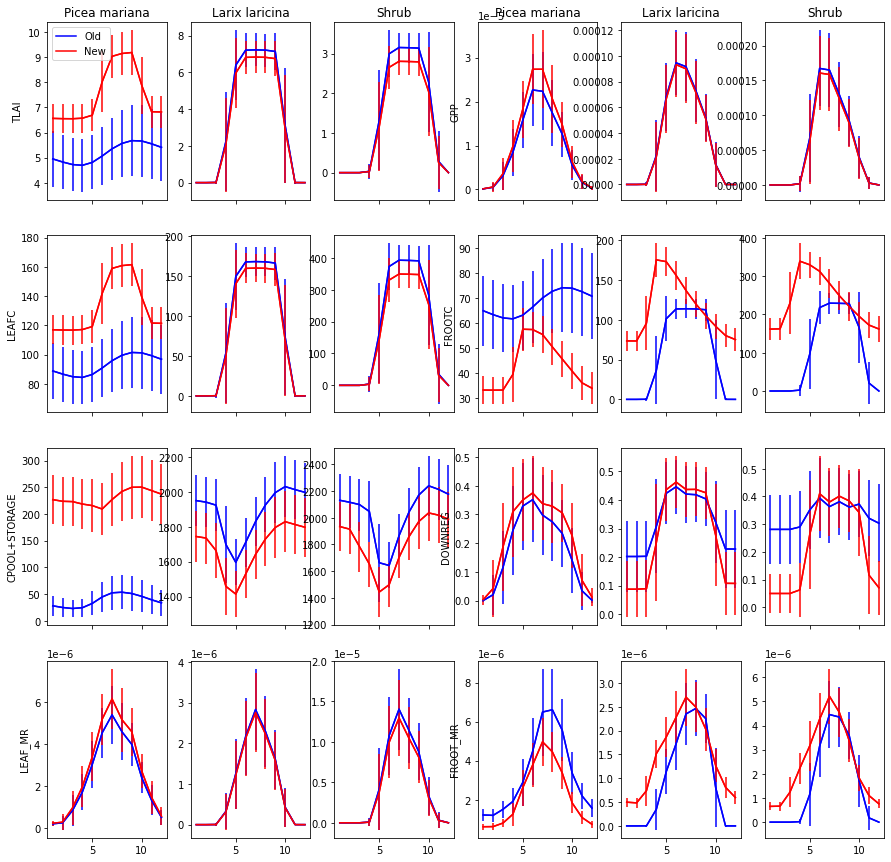

In [49]:
var_list = ['TLAI', 'GPP', 'LEAFC', 'FROOTC', 'CPOOL+STORAGE', 'DOWNREG', 'LEAF_MR', 'FROOT_MR'] #'LEAFC_ALLOC', 'FROOTC_ALLOC', 'CPOOL_TO_LEAFC_STORAGE', 'CPOOL_TO_FROOTC_STORAGE', 'NPP']
pft_list = [2, 3, 11]
pft_names = ['Picea mariana', 'Larix laricina', 'Shrub']

fig, axes = plt.subplots(int(np.ceil(len(var_list) / 2)), len(pft_list) * 2,
                             figsize = (15, 15), sharex = True)

for i, var in enumerate(var_list):
    for j, (pft, pft_name) in enumerate(zip(pft_list, pft_names)):
        ax = axes[int(np.floor(i/2)), j + len(pft_list) * np.mod(i, 2)]

        for name, color in zip(['Old', 'New'], ['b', 'r']):

            temp0 = data_collection[name]

            if var == 'CPOOL+STORAGE':
                temp = temp0.loc[:, (slice(None), 'TOTVEGC', pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), 'TOTVEGC', pft, 'hollow')].values * 0.36
                for v2 in ['LEAFC', 'LIVESTEMC', 'DEADSTEMC', 'FROOTC', 'LIVECROOTC', 'DEADCROOTC', 
                           'LEAFC_XFER', 'LIVESTEMC_XFER', 'DEADSTEMC_XFER', 'FROOTC_XFER',
                           'LIVECROOTC_XFER', 'DEADCROOTC_XFER', 'GRESP_XFER']:
                    temp2 = temp0.loc[:, (slice(None), v2, pft, 'hummock')] * 0.64 + \
                            temp0.loc[:, (slice(None), v2, pft, 'hollow')].values * 0.36
                    temp = temp - temp2.values
            else:
                temp = temp0.loc[:, (slice(None), var, pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), var, pft, 'hollow')].values * 0.36

            temp_mean = temp.groupby(temp.index.month).mean().mean(axis = 1)
            temp_std = temp.groupby(temp.index.month).apply(lambda x: x.values.reshape(-1).std())

            ## normalize to annual average = 1
            #temp_std = temp_std / temp_mean.mean()
            #temp_mean = temp_mean / temp_mean.mean()

            ax.plot(range(1, 13), temp_mean, '-', color = color, label = name)
            ax.errorbar(range(1, 13), temp_mean, yerr = temp_std, ls = '-', color = color)

        if i < 2:
            ax.set_title(pft_name)
        if j == 0:
            ax.set_ylabel(var)
            if i == 0:
                ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality.png'), 
            dpi = 600., bbox_inches = 'tight')

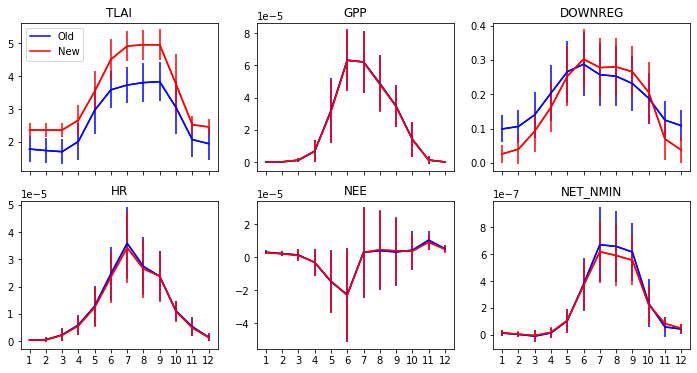

In [4]:
#var_list = ['TSOI_3', 'SWC_1', 'HR', 'NEE', 'NET_NMIN', 'BTRAN']
var_list = ['TLAI', 'GPP', 'DOWNREG', 'HR', 'NEE', 'NET_NMIN'] # , 'BTRAN']

fig, axes = plt.subplots(2, 3, figsize = (12, 6), sharex = True)
#fig, axes = plt.subplots(2, 2, figsize = (10, 6), sharex = True)

for i, var in enumerate(var_list):
    ax = axes.flat[i]

    for name, color in zip(['Old', 'New'], ['b', 'r']):

        temp0 = data_collection[name]

        if var in ['TLAI', 'GPP', 'NPP', 'DOWNREG']:
            temp = {}
            for pft in [2, 3, 11, 12]:
                temp[pft] = temp0.loc[:, (slice(None), var, pft, 'hummock')] * 0.64 + \
                            temp0.loc[:, (slice(None), var, pft, 'hollow')].values * 0.36
            temp = temp[2] * 0.36 + temp[3].values * 0.14 + temp[11].values * 0.25
        else:
            temp = temp0.loc[:, (slice(None), var, 0, 'hummock')] * 0.64 + \
                temp0.loc[:, (slice(None), var, 0, 'hollow')].values * 0.36

        temp_mean = temp.groupby(temp.index.month).mean().mean(axis = 1)
        temp_std = temp.groupby(temp.index.month).apply(lambda x: x.values.reshape(-1).std())

        ## normalize to annual average = 1
        #temp_std = temp_std / temp_mean.mean()
        #temp_mean = temp_mean / temp_mean.mean()

        ax.plot(range(1, 13), temp_mean, '-', color = color, label = name)
        ax.errorbar(range(1, 13), temp_mean, yerr = temp_std, ls = '-', color = color)

    ax.set_title(var)
    ax.set_xticks(range(1, 13))
    if i == 0:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality2.png'), 
            dpi = 600., bbox_inches = 'tight')

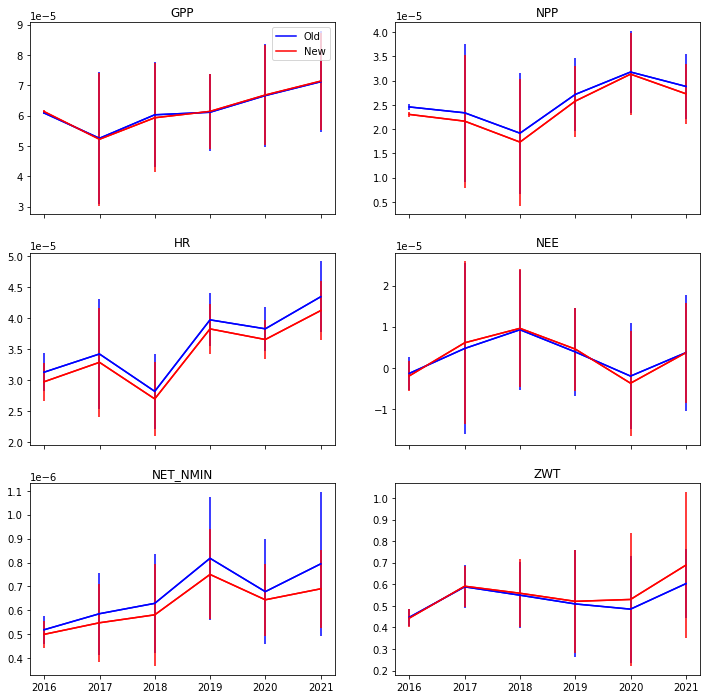

In [51]:
#var_list = ['TSOI_3', 'SWC_1', 'HR', 'NEE', 'NET_NMIN', 'BTRAN']
var_list = ['GPP', 'NPP', 'HR', 'NEE', 'NET_NMIN', 'ZWT']

fig, axes = plt.subplots(3, 2, figsize = (12, 12), sharex = True)

for i, var in enumerate(var_list):
    ax = axes.flat[i]

    for name, color in zip(['Old', 'New'], ['b', 'r']):

        temp0 = data_collection[name]

        if var in ['GPP', 'NPP']:
            temp = {}
            for pft in [2, 3, 11]:
                temp[pft] = temp0.loc[:, (slice(None), var, pft, 'hummock')] * 0.64 + \
                            temp0.loc[:, (slice(None), var, pft, 'hollow')].values * 0.36
            temp = temp[2] * 0.36 + temp[3].values * 0.14 + temp[11].values * 0.25
        else:
            temp = temp0.loc[:, (slice(None), var, 0, 'hummock')] * 0.64 + \
                   temp0.loc[:, (slice(None), var, 0, 'hollow')].values * 0.36
        
        # subset to July
        temp = temp.loc[temp.index.month == 7, :]

        temp_mean = temp.resample('1Y').mean().mean(axis = 1)
        temp_std = temp.resample('1Y').mean().std(axis = 1)

        ax.plot(temp_mean.index, temp_mean, '-', color = color, label = name)
        ax.errorbar(temp_mean.index, temp_mean, yerr = temp_std, ls = '-', color = color)

    ax.set_title(var)
    if i == 0:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_monthly2.png'), 
            dpi = 600., bbox_inches = 'tight')

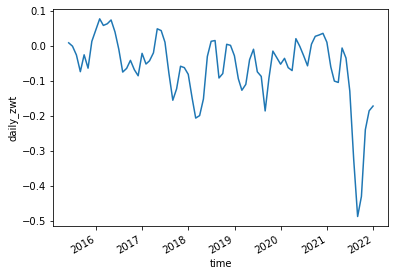

In [96]:
hr = xr.open_dataset(os.path.join(path_intrim, 'spruce_validation_data.nc'))
hr['daily_zwt'].resample(time = '1M').mean().mean(axis = 1).plot()

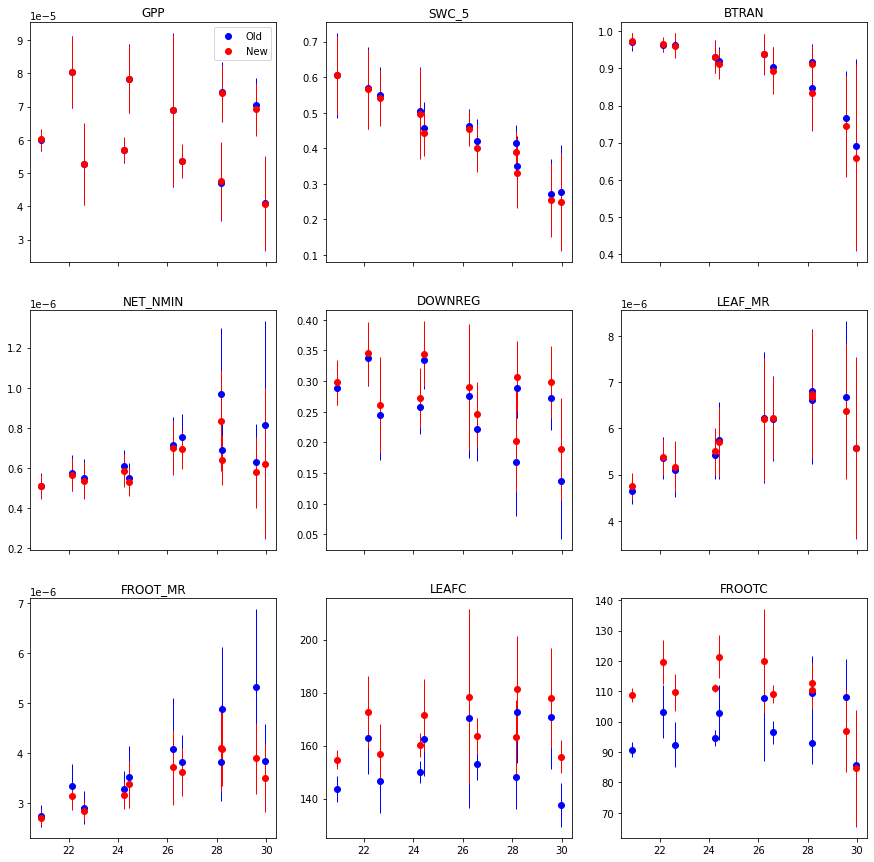

In [95]:
#var_list = ['TSOI_3', 'SWC_1', 'HR', 'NEE', 'NET_NMIN', 'BTRAN']
var_list = ['GPP', 'SWC_5', 'BTRAN', 'NET_NMIN', 'DOWNREG', 'LEAF_MR', 'FROOT_MR', 'LEAFC', 'FROOTC'] # ZWT has too much negative bias to be useful

fig, axes = plt.subplots(3, 3, figsize = (15, 15), sharex = True)

for i, var in enumerate(var_list):
    ax = axes.flat[i]

    for name, color in zip(['Old', 'New'], ['b', 'r']):

        temp0 = data_collection[name]

        if var in ['GPP', 'DOWNREG', 'NPP', 'LEAF_MR', 'FROOT_MR', 'LEAFC', 'FROOTC']:
            temp = {}
            for pft in [2, 3, 11]:
                temp[pft] = temp0.loc[:, (slice(None), var, pft, 'hummock')] * 0.64 + \
                            temp0.loc[:, (slice(None), var, pft, 'hollow')].values * 0.36
            temp = temp[2] * 0.36 + temp[3].values * 0.14 + temp[11].values * 0.25
        else:
            temp = temp0.loc[:, (slice(None), var, 0, 'hummock')] * 0.64 + \
                   temp0.loc[:, (slice(None), var, 0, 'hollow')].values * 0.36

        temp2 = (temp0.loc[:, (slice(None), 'TBOT', 0, 'hummock')] - 273.15) * 0.64 + \
                (temp0.loc[:, (slice(None), 'TBOT', 0, 'hollow')].values - 273.15) * 0.36

        # subset to July
        temp = temp.loc[temp.index.month == 7, :]
        temp2 = temp2.loc[temp2.index.month == 7, :]

        temp_mean = temp.resample('1Y').mean().mean(axis = 0)
        temp_std = temp.resample('1Y').mean().std(axis = 0)

        temp2_mean = temp2.resample('1Y').mean().mean(axis = 0)

        ax.plot(temp2_mean, temp_mean, 'o', color = color, label = name)
        ax.errorbar(temp2_mean, temp_mean, yerr = temp_std, lw = 0, elinewidth = 1, color = color)

    ax.set_title(var)
    if i == 0:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_temperature_sensitivity.png'), 
            dpi = 600., bbox_inches = 'tight')

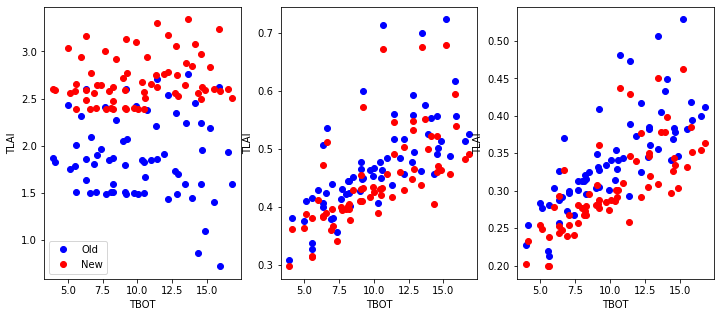

In [94]:
x_var = 'TBOT'
y_var = 'TLAI'
# x_var = 'DOWNREG'
# y_var = 'FROOTC_ALLOC'

fig, axes = plt.subplots(1, 3, figsize = (12, 5))

for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]

    for name, color in zip(['Old', 'New'], ['b', 'r']):

        temp0 = data_collection[name]

        if y_var not in ['TBOT', 'TSOI_3', 'SWC_1', 'SWC_5', 'HR', 'NEE', 'NET_NMIN', 'BTRAN']:
            if '/' in y_var:
                a = y_var.split('/')[0]
                b = y_var.split('/')[1]
                temp = temp0.loc[:, (slice(None), a, pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), a, pft, 'hollow')].values * 0.36
                temp3 = temp0.loc[:, (slice(None), b, pft, 'hummock')] * 0.64 + \
                        temp0.loc[:, (slice(None), b, pft, 'hollow')].values * 0.36
                temp_mean = temp.resample('1Y').mean() / temp3.resample('1Y').mean().values
            else:
                temp = temp0.loc[:, (slice(None), y_var, pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), y_var, pft, 'hollow')].values * 0.36
                temp_mean = temp.resample('1Y').mean()
            if pft == 2:
                temp_mean = temp_mean * 0.36
            elif pft == 3:
                temp_mean = temp_mean * 0.14
            else:
                temp_mean = temp_mean * 0.25
        else:
            temp = temp0.loc[:, (slice(None), y_var, 0, 'hummock')] * 0.64 + \
                   temp0.loc[:, (slice(None), y_var, 0, 'hollow')].values * 0.36
            temp_mean = temp.resample('1Y').mean()

        if x_var not in ['TBOT', 'TSOI_3', 'SWC_1', 'SWC_5', 'HR', 'NEE', 'NET_NMIN', 'BTRAN']:
            if '/' in x_var:
                a = x_var.split('/')[0]
                b = x_var.split('/')[1]
                temp2 = temp0.loc[:, (slice(None), a, pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), a, pft, 'hollow')].values * 0.36
                temp3 = temp0.loc[:, (slice(None), b, pft, 'hummock')] * 0.64 + \
                        temp0.loc[:, (slice(None), b, pft, 'hollow')].values * 0.36
                temp2_mean = temp2.resample('1Y').mean() / temp3.resample('1Y').mean().values
            else:
                temp2 = temp0.loc[:, (slice(None), x_var, pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), x_var, pft, 'hollow')].values * 0.36
                temp2_mean = temp2.resample('1Y').mean()
            if pft == 2:
                temp2_mean = temp2_mean * 0.36
            elif pft == 3:
                temp2_mean = temp2_mean * 0.14
            else:
                temp2_mean = temp2_mean * 0.25
        else:
            temp2 = temp0.loc[:, (slice(None), x_var, 0, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), x_var, 0, 'hollow')].values * 0.36
            if x_var == 'TBOT':
                temp2 = temp2 - 273.15
            temp2_mean = temp2.resample('1Y').mean()

        ax.plot(temp2_mean.values.reshape(-1), temp_mean.values.reshape(-1), 'o', color = color, label = name)

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    if i == 0:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_relation_1.png'), 
            dpi = 600., bbox_inches = 'tight')

## Test observed water table driven simulations

In [9]:
print(chamber_list_complete)
print(chamber_list_names_complete)

[7, 6, 19, 20, 11, 13, 4, 8, 16, 17, 10]
['TAMB', 'T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2']
